In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.models import (resnet50, ResNet50_Weights)
from torchvision.models import (resnet18, ResNet18_Weights)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

from tqdm import tqdm
import math
from PIL import Image
import json
import time
import os

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
#df = pd.read_parquet("Data/archived_data/dipser_transformed_data.parquet", engine="pyarrow")
df = pd.read_parquet("Data/dipser_dataset.parquet", engine="pyarrow")

In [3]:
df["time_sec"] = (pd.to_datetime(df["time"]))

# convert it to 0-300
df["time_sec"] = (
    df.groupby("subject_experiment_id")["time_sec"]
    .transform(lambda x:
        (x - x.min())
        .dt.total_seconds()
        .astype(int)
    )
)
df.head()

,group,time,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,gender,age,race,subject_experiment_id,attention,subject_id,time_sec
0,group01,2026-05-08 10:40:43.047895,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
1,group01,2026-05-08 10:40:43.195317,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_195317.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_195317.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109485,0.000109,-0.660015,0.000520,0.632620,0.000426,0.390106,0.000225,246.0,0.0,-0.004508,0.005235,-0.004068,0.003267,-0.001026,0.005944,0.053056,0.036979,-0.124020,0.045047,0.012282,0.043478,63.0,0.0,78.0,NaN,0.148634,0.038779,0.009572,0.004378,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
2,group01,2026-05-08 10:40:43.295405,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_295405.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_295405.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109478,0.000101,-0.660194,0.000514,0.632473,0.000406,0.390043,0.000252,246.0,0.0,-0.004581,0.005193,-0.003897,0.003153,-0.000525,0.005644,0.054420,0.036670,-0.129478,0.044805,0.015730,0.040968,63.0,0.0,78.0,NaN,0.153129,0.038995,0.009384,0.004079,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
3,group01,2026-05-08 10:40:43.395835,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_395835.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_395835.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
# df.isna().sum().head(60)

In [5]:
df[['attention', 'age', 'gender', 'image_path']].isna().sum()

attention     0
age           0
gender        0
image_path    0
dtype: int64

In [6]:
# keep only 1 frame per second (the first)
df_sec = (df.sort_values("time")
      .groupby(["subject_experiment_id", "time_sec"])
      .first()
      .reset_index())

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])

# transform = transforms.Compose([
#     transforms.Resize((224, 224)),

#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(10),
#     transforms.ColorJitter(
#         brightness=0.2,
#         contrast=0.2,
#         saturation=0.1
#     ),

#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

In [8]:
class DipserImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row["attention"], dtype=torch.float32)

        return img, label, idx

# Train Test Split

We split by group subject to ensure there is no leakage (the same subject be present in train and test set in a different experiment).

In [9]:
subject_df = df[['subject_id', 'gender']].drop_duplicates()

train_sub, temp_sub = train_test_split(
    subject_df,
    test_size=0.3,
    stratify=subject_df['gender'],
    random_state=42)

# further break temp for balanced val and test
val_sub, test_sub = train_test_split(
    temp_sub,
    test_size=0.5,
    stratify=temp_sub['gender'],
    random_state=42)

train_subjects = train_sub['subject_id']
val_subjects = val_sub['subject_id']
test_subjects = test_sub['subject_id']

train_df = df_sec[df_sec["subject_id"].isin(train_subjects)]
val_df  = df_sec[df_sec["subject_id"].isin(val_subjects)]
test_df  = df_sec[df_sec["subject_id"].isin(test_subjects)]

In [10]:
train_dataset = DipserImageDataset(train_df, transform)
val_dataset = DipserImageDataset(val_df, transform)
test_dataset  = DipserImageDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

# Training

In [11]:
# resnet50
# class AttentionCNN(nn.Module):
#     def __init__(self, freeze_backbone=True):
#         super().__init__()

#         self.backbone = models.resnet50(pretrained=True)

#         if freeze_backbone:
#             for p in self.backbone.parameters():
#                 p.requires_grad = False

#         in_features = self.backbone.fc.in_features
#         self.backbone.fc = nn.Identity()

#         self.head = nn.Sequential(
#             nn.Linear(in_features, 256),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.Dropout(0.4),
        
#             nn.Linear(256, 64),
#             nn.ReLU(),
        
#             nn.Linear(64, 1)
#         )

#     def forward(self, x):
#         x = self.backbone(x)      # (B, 2048)
#         x = self.head(x)          # (B, 1)
#         return x.squeeze(1)


# resnet50
class AttentionCNN(nn.Module):
    def __init__(self, freeze_backbone=True):
        super().__init__()

        self.backbone = models.resnet50(pretrained=True)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.backbone(x)      # (B, 2048)
        x = self.head(x)          # (B, 1)
        return x.squeeze(1)

In [12]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    preds_all = []
    labels_all = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for imgs, labels, _ in pbar:
        imgs, labels = imgs.to(device), labels.to(device)

        preds = model(imgs)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    # compute metrics
    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

In [13]:
def evaluate(model, loader):
    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for imgs, labels, _ in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)
            preds = preds.cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    mae = mean_absolute_error(labels_all, preds_all)
    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return mae, rmse, np.mean(inference_times)

In [14]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, model_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None
        self.best_epoch = None
        self.model_path = model_path

    def step(self, metric, model, epoch):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0

            self.best_model = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch

            if self.model_path is not None:
                torch.save(self.best_model, self.model_path)

            return False  # continue

        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            return self.counter >= self.patience

In [15]:
name = 'resnet50'
model_path = f"models/CNN Static/{name}_baseline.pt"
model_results = f"results/CNN Static/{name}_results.json"
model_figs = f"figs/CNN Static/{name}_training_curves.png"

In [16]:
criterion = nn.L1Loss() # minimize MAE
#criterion = nn.MSELoss() # minimize RMSE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionCNN(freeze_backbone=False).to(device)
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min', factor=0.3, patience=3)

/home/cfragkiadakis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cfragkiadakis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [34]:
early_stopping = EarlyStopping(patience=7, model_path=model_path)
NUM_EPOCHS = 50
train_losses = []
train_mae_list, train_rmse_list = [], []
val_mae_list, val_rmse_list = [], []

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time = evaluate(model, val_loader)

    # --- store metrics ---
    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)

    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)

    # --- logging ---
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")


    # --- scheduler ---
    scheduler.step(val_mae)

    # --- early stopping ---
    stop = early_stopping.step(val_mae, model, epoch)
    best_epoch = early_stopping.best_epoch 
    
    if stop:
        print("Early stopping triggered")
        break

training_end = time.time()

print('Training time:', training_end - training_start)


Epoch 1
Train Loss: 0.1719
Train MAE: 0.3065 | Train RMSE: 0.4146
Val MAE: 0.3587 | Val RMSE: 0.4528



Epoch 2
Train Loss: 0.1173
Train MAE: 0.2675 | Train RMSE: 0.3424
Val MAE: 0.3766 | Val RMSE: 0.4754
EarlyStopping counter: 1/7



Epoch 3
Train Loss: 0.1096
Train MAE: 0.2584 | Train RMSE: 0.3311
Val MAE: 0.3257 | Val RMSE: 0.4121



Epoch 4
Train Loss: 0.1019
Train MAE: 0.2496 | Train RMSE: 0.3192
Val MAE: 0.3466 | Val RMSE: 0.4397
EarlyStopping counter: 1/7



Epoch 5
Train Loss: 0.0965
Train MAE: 0.2436 | Train RMSE: 0.3107
Val MAE: 0.3516 | Val RMSE: 0.4444
EarlyStopping counter: 2/7



Epoch 6
Train Loss: 0.0916
Train MAE: 0.2375 | Train RMSE: 0.3027
Val MAE: 0.3305 | Val RMSE: 0.4176
EarlyStopping counter: 3/7



Epoch 7
Train Loss: 0.0868
Train MAE: 0.2309 | Train RMSE: 0.2945
Val MAE: 0.3430 | Val RMSE: 0.4309
EarlyStopping counter: 4/7



Epoch 8
Train Loss: 0.0755
Train MAE: 0.2162 | Train RMSE: 0.2748
Val MAE: 0.3456 | Val RMSE: 0.4433
EarlyStopping counter: 5/7



Epoch 9
Train Loss: 0.0715
Train MAE: 0.2106 | Train RMSE: 0.2675
Val MAE: 0.3429 | Val RMSE: 0.4358
EarlyStopping counter: 6/7



Epoch 10
Train Loss: 0.0690
Train MAE: 0.2065 | Train RMSE: 0.2626
Val MAE: 0.3456 | Val RMSE: 0.4406
EarlyStopping counter: 7/7
Early stopping triggered
Training time: 3794.60604262352


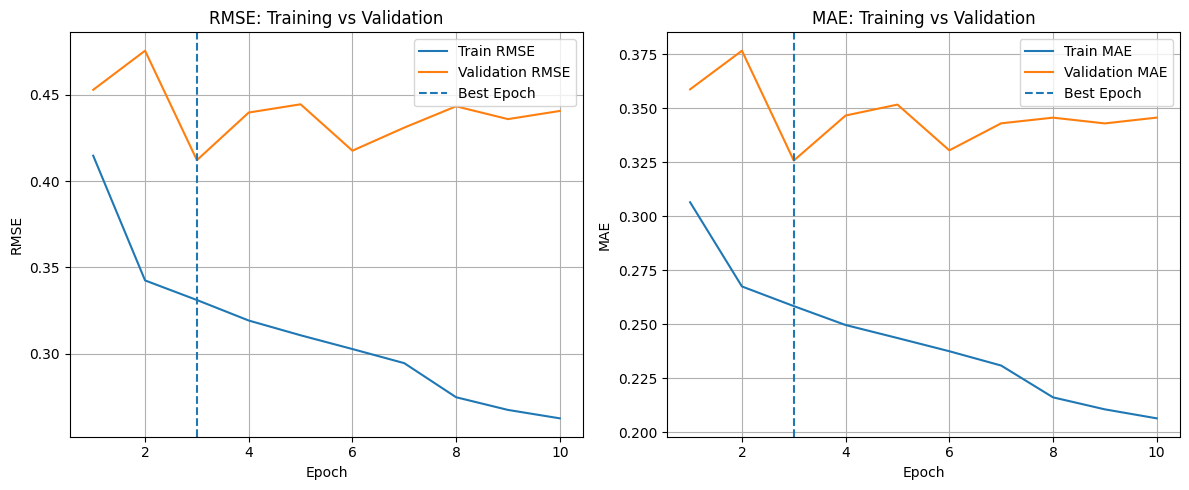

In [35]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig(model_figs, dpi=300, bbox_inches="tight")
plt.show()

### Evaluation on test set

In [17]:
def collect_predictions(model, df, loader):

    model.eval()

    results = []

    all_preds = []

    total_time = 0
    total_samples = 0

    with torch.no_grad():

        pbar = tqdm(loader, desc="Evaluating")

        for imgs, labels, idx in pbar:

            imgs = imgs.to(device)

            start = time.time()

            preds = model(imgs)

            end = time.time()

            batch_time = end - start

            total_time += batch_time
            total_samples += imgs.size(0)

            preds = preds.squeeze().cpu().numpy()

            all_preds.extend(preds)

            for i in range(len(preds)):

                row = df.iloc[idx[i].item()]

                results.append({
                    "pred": float(preds[i]),
                    "true": float(labels[i].item()),
                    "gender": row["gender"],
                    "age": row["age"]
                })

    results_df = pd.DataFrame(results)

    mae = np.mean(np.abs(results_df["true"] - results_df["pred"]))

    rmse = np.sqrt(np.mean((results_df["true"] - results_df["pred"])**2))

    latency_per_batch = total_time / len(loader)
    latency_per_sample = total_time / total_samples

    return (
        np.array(all_preds),
        results_df,
        mae,
        rmse,
        latency_per_batch,
        latency_per_sample)

In [18]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))

    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group

    return group_mae, worst_group, gap

In [19]:
def compute_fairness_metrics(results_df):
    metrics = {}

    # ---- Gender ----
    gender_mae, gender_worst, gender_gap = compute_group_mae(results_df, "gender")

    metrics["gender"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in gender_mae.items()},
        "worst_group_mae": round(float(gender_worst), 5),
        "gap": round(float(gender_gap), 5)
    }

    # ---- Age ----
    results_df = results_df.copy()
    results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])

    age_mae, age_worst, age_gap = compute_group_mae(results_df, "age_group")

    metrics["age"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in age_mae.items()},
        "worst_group_mae": round(float(age_worst), 5),
        "gap": round(float(age_gap), 5)
    }

    return metrics

In [20]:
# replace Nan with None for json export
def replace_nan(d, value=None):
    if isinstance(d, dict):
        return {
            k: replace_nan(v, value)
            for k, v in d.items()
        }
    if isinstance(d, float) and math.isnan(d):
        return value
    return d

In [21]:
# model_path = "models/resnet50_baseline.pt"
# model_results = "results/resnet50_results.json"

model = AttentionCNN(freeze_backbone=False).to(device)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

/scratch-local/cfragkiadakis.22732580/ipykernel_133786/3620736637.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


AttentionCNN(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
    

In [22]:
preds, results_df, best_mae, best_rmse, best_latency_batch, best_latency_sample = collect_predictions(model, test_df, test_loader)
fairness_metrics = compute_fairness_metrics(results_df)
results = {
    "mae": round(float(best_mae),4),
    "rmse": round(float(best_rmse),4),
    "latency_per_batch": round(float(best_latency_batch),4),
    "latency_per_sample_ms": round(float(best_latency_sample * 1000),4),
    "fairness": fairness_metrics
}
clean_results = replace_nan(results, value=None)
with open(model_results, "w") as f:
    json.dump(clean_results, f, indent=4)

Evaluating: 100%|██████████| 282/282 [01:28<00:00,  3.19it/s]
/scratch-local/cfragkiadakis.22732580/ipykernel_133786/38029496.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.22732580/ipykernel_133786/38029496.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.22732580/i

In [23]:
print('MAE:', results['mae'])

MAE: 0.3094


In [24]:
print("MAE per gender:\n", results['fairness']['gender']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['gender']['worst_group_mae']}")
print(f"Gap: {results['fairness']['gender']['gap']}")

MAE per gender:
 {'female': 0.29461, 'male': 0.34818}

Worst-group MAE: 0.34818
Gap: 0.05357


In [25]:
print("MAE per age:\n", results['fairness']['age']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['age']['worst_group_mae']}")
print(f"Gap: {results['fairness']['age']['gap']}")

MAE per age:
 {'(13, 17]': 0.28791, '(17, 20]': 0.18567, '(20, 22]': 0.33646, '(22, 26]': 0.3633, '(26, 44]': 0.26641}

Worst-group MAE: 0.3633
Gap: 0.17763


In [26]:
print(preds.min())
print(preds.max())
print(preds.mean())
print(preds.std())

2.3220494
3.9091668
2.9345748
0.19864649


In [27]:
mean_pred = train_df["attention"].mean()

baseline_mae = (
    test_df["attention"] - mean_pred
).abs().mean()

print(mean_pred)
print(baseline_mae)

2.929249676584735
0.32466260227715943


In [28]:
from sklearn.metrics import r2_score

print(r2_score(test_df['attention'], preds))

0.07686709958573812


In [33]:
results_df["bin"] = pd.cut(
    results_df["true"],
    bins=[1,2,2.5,3,3.5,4,5]
)

results_df.groupby("bin").apply(
    lambda x: np.mean(
        np.abs(x["true"] - x["pred"])))

/scratch-local/cfragkiadakis.22732580/ipykernel_133786/944789504.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby("bin").apply(
/scratch-local/cfragkiadakis.22732580/ipykernel_133786/944789504.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_df.groupby("bin").apply(


bin
(1.0, 2.0]    0.953620
(2.0, 2.5]    0.457413
(2.5, 3.0]    0.152622
(3.0, 3.5]    0.395070
(3.5, 4.0]    0.665014
(4.0, 5.0]    1.138593
dtype: float64